# Portfolio Weights Analysis
Here we analyze the weights produced by the AttentionLSTM-custom_loss_11 (CustomLossB) model.

In [1]:
# All imports
import os
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.io import load_path_config, load_json
from src.utils.formatting import deserialize_np_dict
from src.data_processing.loading import load_single_csv

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

We use best seed found for the best model in the file test_analysis.ipynb.

In [3]:
best_model = 'AttentionLSTM-custom_loss_11'
best_seed = 434445 ####

best_bench = 'NestedClusteredOptimization'

In [4]:
all_seed_wts = load_json(artifacts_paths['test_perf_dir'] / 'test_weights_all.json')
all_seed_wts.keys()

dict_keys(['nn_models', 'benchmarks'])

In [5]:
# REMOVE NAIVE MVP
if 'NaiveMVP' in all_seed_wts['benchmarks']:
    del all_seed_wts['benchmarks']['NaiveMVP']
    print('NaiveMVP removed!')

NaiveMVP removed!


In [6]:
# Extract all needed weights
# best_model_wts = deserialize_np_dict(all_seed_wts['nn_models'][best_model][f'{best_seed}'])
# bench_wts = deserialize_np_dict(all_seed_wts['benchmarks'])

all_wts = {
    best_model: deserialize_np_dict(all_seed_wts['nn_models'][best_model][f'{best_seed}'])
}
all_wts.update(deserialize_np_dict(all_seed_wts['benchmarks']))


## Turnover Analysis

In [7]:
num_steps = all_wts[best_model].shape[0]
num_stocks = all_wts[best_model].shape[1]
initial_wts = np.zeros(num_stocks)

quarterly_turnover = {}

for model, wts in all_wts.items():
    turnovers = []
    for step in range(num_steps):
        if step == 0:
            prev_w = np.zeros(num_stocks)
        else:
            prev_w = wts[step-1]
        # Turnover is sum of absolute differences
        turnover = 0.5 * np.sum(np.abs(wts[step] - prev_w))
        turnovers.append(turnover)
    quarterly_turnover[model] = turnovers

pd.DataFrame(quarterly_turnover)

,AttentionLSTM-custom_loss_11,GlobalMinimumVariance,MeanVariancePortfolio,HierarchialRiskParity,NestedClusteredOptimization,EqualRiskContribution
0,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
1,0.991589,0.014648,0.129107,0.046365,0.034100,0.001572
2,0.605818,0.013524,0.062055,0.116733,0.068748,0.002143
3,0.986648,0.009945,0.114031,0.030945,0.023181,0.001308
4,0.536484,0.015451,0.133180,0.020254,0.032748,0.002824
5,0.633985,0.008230,0.091436,0.095851,0.027840,0.001278
6,0.701598,0.004496,0.074788,0.034348,0.012285,0.000891
7,0.860678,0.007154,0.217310,0.080353,0.031535,0.000457


## Sector Exposure

In [8]:
# Sector - Ticker Mapping
sector_mapping = {
    'Basic_Materials': ['EMN', 'STLD'], 
    'Consumer_Cyclical': ['DECK', 'DPZ', 'KMX', 'MHK', 'NVR', 'PKG'], 
    'Consumer_Defensive': ['CAG', 'CPB', 'KMB'], 
    'Financial_Services': ['CINF', 'FDS', 'HBAN', 'IVZ', 'NTRS', 'TRV', 'WRB'],
    'Healthcare': ['COO', 'DVA', 'HOLX', 'HSIC', 'LH', 'PODD', 'TECH', 'TFX', 'UHS'],
    'Industrials': ['CHRW', 'EXPD', 'IEX', 'JBHT', 'NDSN', 'RHI'],
    'Real_Estate': ['BXP', 'CPT', 'ESS', 'EXR', 'FRT', 'IRM', 'KIM', 'REG'],
    'Technology': ['AKAM', 'FFIV', 'JKHY', 'TRMB'], 
    'Utilities': ['ATO', 'ED', 'EIX', 'ETR', 'LNT']
}

In [9]:
tickers = list(load_single_csv(paths_config['processed_paths']['returns_test']).columns)
print('Number of Tickers =', len(tickers))

Number of Tickers = 50


In [10]:
best_model_wts = pd.DataFrame(all_wts[best_model], columns=tickers)
best_model_wts

,AKAM,ATO,BXP,CAG,CHRW,CINF,COO,CPB,CPT,DECK,...,PODD,REG,RHI,STLD,TECH,TFX,TRMB,TRV,UHS,WRB
0,4.513962e-02,9.080332e-07,1.821910e-02,0.000005,2.893311e-05,2.270094e-07,0.000003,7.026189e-06,0.312607,3.713917e-03,...,5.136750e-06,0.094516,6.662188e-02,3.606701e-03,1.903159e-04,0.000001,1.075267e-04,5.215893e-07,0.000067,3.003934e-07
1,1.545585e-07,2.784546e-01,8.606338e-05,0.000008,2.922039e-03,1.060810e-01,0.000004,4.860317e-02,0.000066,4.328830e-07,...,8.039688e-07,0.001093,2.740938e-07,1.230232e-07,8.805064e-07,0.000013,4.950815e-06,1.607095e-01,0.000007,8.055688e-02
2,2.493446e-06,7.946855e-02,3.233932e-05,0.000002,5.619482e-02,2.348344e-02,0.000692,2.207122e-01,0.002303,3.015516e-06,...,8.977677e-04,0.000415,9.255514e-06,2.849920e-05,6.330907e-06,0.000027,9.338952e-07,1.825428e-02,0.000003,8.531480e-02
3,1.493114e-04,1.653286e-05,3.974812e-05,0.000001,3.169860e-03,7.485697e-05,0.005784,7.487024e-05,0.001833,1.271880e-01,...,3.759152e-02,0.000151,4.886356e-02,1.164963e-01,6.189212e-03,0.000071,2.340452e-02,2.726073e-05,0.000003,2.463090e-04
4,1.045618e-03,7.072010e-07,1.661774e-06,0.000259,3.247748e-07,1.683679e-05,0.000177,2.151816e-07,0.000040,2.147081e-01,...,1.588006e-01,0.000115,2.941038e-02,2.566685e-01,3.714036e-03,0.004010,4.932786e-03,1.043629e-05,0.000008,7.392545e-06
5,7.080651e-05,6.339333e-06,2.948642e-07,0.000020,9.576540e-07,1.224528e-02,0.000174,2.840301e-05,0.000002,3.336269e-02,...,5.055022e-02,0.000063,1.197273e-04,1.120016e-01,3.599652e-05,0.072076,2.375306e-02,1.996805e-03,0.000002,2.793457e-03
6,1.236985e-04,4.165052e-05,2.720213e-05,0.000087,2.131139e-06,9.492442e-05,0.177531,4.617383e-06,0.002652,1.999861e-01,...,1.001882e-01,0.000063,5.838810e-05,4.919869e-04,1.212273e-01,0.001260,3.938020e-03,6.799371e-06,0.001178,4.331177e-06
7,2.470980e-01,7.347497e-06,1.356991e-01,0.000004,4.942746e-06,2.852683e-05,0.011057,3.379922e-07,0.010349,8.206350e-02,...,1.562302e-03,0.000503,2.585740e-02,2.387794e-03,4.025773e-04,0.000018,1.040448e-02,5.202126e-06,0.001615,4.201516e-06


In [ ]:
# Invert mapping
ticker_to_sector = {}
for sector, sector_tickers in sector_mapping.items():
    for ticker in sector_tickers:
        ticker_to_sector[ticker] = sector

# Group by sector
sector_weights = best_model_wts.T.groupby(by=ticker_to_sector).sum().T

# Check that weights sum to 1 for each step
print(sector_weights.sum(axis=1))  # Should be all 1.0

50
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
dtype: float64
50


In [12]:
sector_weights

,Basic_Materials,Consumer_Cyclical,Consumer_Defensive,Financial_Services,Healthcare,Industrials,Real_Estate,Technology,Utilities
0,3.977560e-03,0.007660,0.000013,0.007509,0.001518,0.066902,0.733290,0.178879,0.000250
1,4.315807e-07,0.000306,0.064934,0.347375,0.163330,0.003363,0.007659,0.000018,0.413014
2,2.950896e-05,0.000798,0.222333,0.127150,0.001873,0.062024,0.011140,0.000343,0.574309
3,1.680062e-01,0.207441,0.000086,0.231031,0.049698,0.294028,0.014245,0.035027,0.000438
4,2.674353e-01,0.302707,0.000259,0.077413,0.166733,0.175184,0.000810,0.009456,0.000002
5,1.285676e-01,0.560036,0.000052,0.096419,0.123061,0.065998,0.000626,0.024359,0.000882
6,2.289428e-03,0.471509,0.000236,0.019051,0.403861,0.027318,0.070846,0.004541,0.000348
7,6.688825e-03,0.374919,0.000170,0.003583,0.023647,0.029138,0.183315,0.378502,0.000038


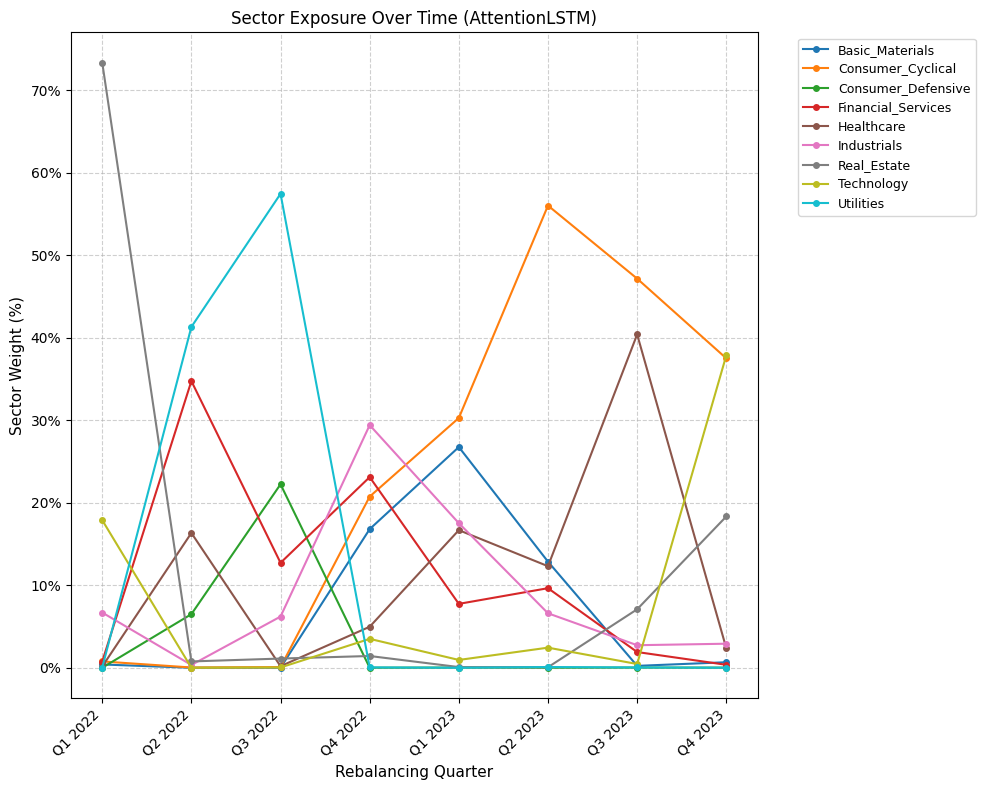

In [13]:
# Assuming sector_weights is your DataFrame
date_labels = ['Q1 2022', 'Q2 2022', 'Q3 2022', 'Q4 2022', 
               'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023']

colors = plt.cm.tab10(np.linspace(0, 1, len(sector_weights.columns)))

fig, ax = plt.subplots(figsize=(10, 8))

for i, sector in enumerate(sector_weights.columns):
    ax.plot(sector_weights.index, sector_weights[sector], 
            label=sector, 
            color=colors[i],
            linewidth=1.5,
            marker='o',
            markersize=4)

ax.set_xticks(range(len(date_labels)))
ax.set_xticklabels(date_labels, rotation=45, ha='right')
ax.set_xlabel('Rebalancing Quarter', fontsize=11)
ax.set_ylabel('Sector Weight (%)', fontsize=11)
ax.set_title('Sector Exposure Over Time (AttentionLSTM)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('sector_exposure_attentionlstm.pdf', bbox_inches='tight')
plt.show()

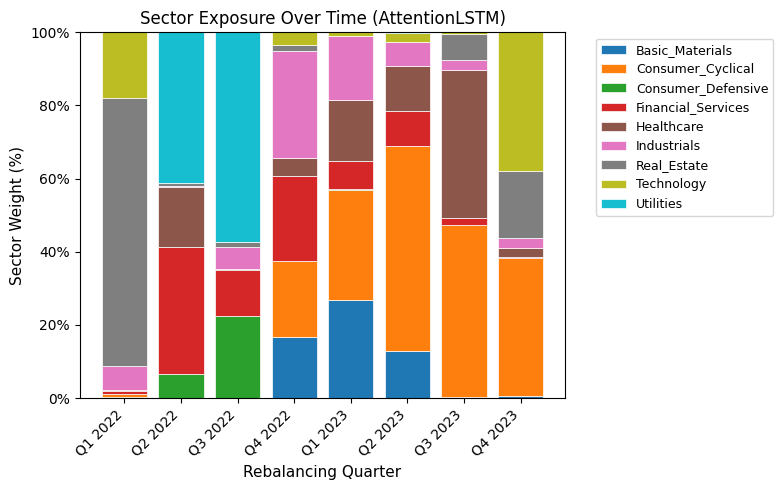

In [ ]:
# Assuming sector_weights is your DataFrame (steps x sectors)

# Define a color palette (colorblind-friendly)
colors = plt.cm.tab10(np.linspace(0, 1, len(sector_weights.columns)))

fig, ax = plt.subplots(figsize=(8, 5))

# Create the stacked bars
bottom = np.zeros(len(sector_weights))
for i, sector in enumerate(sector_weights.columns):
    ax.bar(sector_weights.index, sector_weights[sector], 
           bottom=bottom, 
           label=sector, 
           color=colors[i],
           edgecolor='white',
           linewidth=0.5)
    bottom += sector_weights[sector]

# Formatting
ax.set_xticks(sector_weights.index)
ax.set_xticklabels(date_labels, rotation=45, ha='right')
ax.set_xlabel('Rebalancing Quarter', fontsize=11)
ax.set_ylabel('Sector Weight (%)', fontsize=11)
ax.set_title('Sector Exposure Over Time (AttentionLSTM)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1)  # Weights sum to 1

plt.tight_layout()
plt.savefig('sector_exposure_stacked_bar.pdf', bbox_inches='tight')
plt.show()